# 0.9 Full EIP-7999 Passive Replay

This notebook replays a full EIP-7999-style mechanism on the 500-block sample:

```text
execution:  separated execution gas, normalized fake-exponential base fee
bandwidth:  calldata + BAL + access-list + authorization + blob-hash bytes, normalized fake-exponential base fee
state:      EIP-8037 state gas, normalized fake-exponential base fee, no per-block limit
```

The important difference from Mechanism A is that state is no longer inside `max(execution, state)` and no EIP-1559 update is used. Execution, bandwidth, and state each have their own base fee and excess accumulator.

Following the linked EIP-7999 draft, state has no hard block limit. It normalizes excess-gas deltas by `STATE_GAS_TARGET`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip7999_normalized import BASE_FEE_UPDATE_FRACTION
from mechanisms import (
    PassiveBlockUsage,
    make_full_7999_config,
    replay_full_7999,
)

pd.options.display.float_format = "{:,.4f}".format

## Parameters

For this first full-7999 replay:

- execution target/limit: `30M / 60M`
- bandwidth target/limit: `15M / 60M`
- state target: `75M`
- state limit: none
- bandwidth metering: `16 gas / metered byte`

Execution is seeded from the first historical base fee. Bandwidth and state are new resources, so they start at `1`.

In [2]:
START_BLOCK = 24_120_001
END_BLOCK = 24_120_500

EXECUTION_GAS_LIMIT = 60_000_000
EXECUTION_GAS_TARGET = 30_000_000
EXECUTION_TARGET_RATIO = EXECUTION_GAS_LIMIT // EXECUTION_GAS_TARGET

BANDWIDTH_GAS_PER_BYTE = 16
BANDWIDTH_GAS_LIMIT = 60_000_000
BANDWIDTH_GAS_TARGET = 15_000_000
BANDWIDTH_TARGET_RATIO = BANDWIDTH_GAS_LIMIT // BANDWIDTH_GAS_TARGET
BANDWIDTH_RESERVE_FACTOR = 12

STATE_GAS_TARGET = 75_000_000

INITIAL_EXECUTION_BASE_FEE = 1
INITIAL_BANDWIDTH_BASE_FEE = 1
INITIAL_STATE_BASE_FEE = 1

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

TX_REPRICE_CSV = DATA_DIR / f"glamsterdam_tx_regular_gas_repriced_{START_BLOCK}_{END_BLOCK}.csv"
REGULAR_RECALC_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_{START_BLOCK}_{END_BLOCK}.csv"
BANDWIDTH_CSV = DATA_DIR / f"bandwidth_content_8131_{START_BLOCK}_{END_BLOCK}.csv"
BLOB_BASE_FEE_CSV = DATA_DIR / f"rpc_blob_base_fee_{START_BLOCK}_{END_BLOCK}.csv"

OUT_REPLAY_CSV = DATA_DIR / f"full_7999_replay_{START_BLOCK}_{END_BLOCK}.csv"
OUT_SUMMARY_CSV = DATA_DIR / f"full_7999_summary_{START_BLOCK}_{END_BLOCK}.csv"

OUT_RESOURCE_GAS_PLOT = PLOTS_DIR / f"full_7999_resource_gas_{START_BLOCK}_{END_BLOCK}.png"
OUT_BASE_FEE_PLOT = PLOTS_DIR / f"full_7999_base_fees_{START_BLOCK}_{END_BLOCK}.png"
OUT_EXCESS_PLOT = PLOTS_DIR / f"full_7999_excess_{START_BLOCK}_{END_BLOCK}.png"
OUT_BANDWIDTH_COMPONENTS_PLOT = PLOTS_DIR / f"full_7999_bandwidth_components_{START_BLOCK}_{END_BLOCK}.png"

for path in [TX_REPRICE_CSV, REGULAR_RECALC_CSV, BANDWIDTH_CSV, BLOB_BASE_FEE_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

START_BLOCK, END_BLOCK, EXECUTION_GAS_TARGET, EXECUTION_GAS_LIMIT, BANDWIDTH_GAS_TARGET, BANDWIDTH_GAS_LIMIT, BANDWIDTH_RESERVE_FACTOR, STATE_GAS_TARGET

(24120001, 24120500, 30000000, 60000000, 15000000, 60000000, 12, 75000000)

## Build Passive Inputs

Execution gas is reconstructed the same way as in Mechanism A:

```text
execution_gas_used = historical gas used
  - historical state-creation gas moved into state
  - current calldata charge moved into bandwidth
```

The current calldata charge is transaction-level standard calldata gas plus the observed EIP-7623 floor uplift for calldata-heavy transactions. There is no EIP-7976 or EIP-7981 floor in this full-7999 replay.

Bandwidth gas is a replay convention:

```text
bandwidth_gas = 16 * bandwidth_metered_bytes
```

State gas is the EIP-8037 state-creation gas, but it settles against a dedicated state base fee.

In [3]:
tx = pd.read_csv(TX_REPRICE_CSV)
regular = pd.read_csv(REGULAR_RECALC_CSV)
bandwidth = pd.read_csv(BANDWIDTH_CSV)
blob_fee = pd.read_csv(BLOB_BASE_FEE_CSV)[["block_number", "blob_base_fee_per_gas"]]

# Historical calldata de-accounting: standard 4/16 calldata gas plus observed
# EIP-7623 10/40 floor uplift for calldata-heavy transactions.
tx["current_calldata_deaccounted_gas"] = tx["standard_calldata_gas"].astype("int64")
floor_mask = tx["current_floor_binds_observed"].astype(bool)
tx.loc[floor_mask, "current_calldata_deaccounted_gas"] = tx.loc[
    floor_mask,
    "current_7623_floor_gas",
].astype("int64")
tx["current_7623_floor_uplift_observed"] = (
    tx["current_calldata_deaccounted_gas"]
    - tx["standard_calldata_gas"].astype("int64")
)

tx_agg = (
    tx.groupby("block_number", as_index=False)
    .agg(
        tx_count=("tx_hash", "count"),
        current_gas_used_from_txs=("receipt_gas_used", "sum"),
        standard_calldata_gas_current=("standard_calldata_gas", "sum"),
        current_calldata_deaccounted_gas=("current_calldata_deaccounted_gas", "sum"),
        current_7623_floor_uplift_observed=("current_7623_floor_uplift_observed", "sum"),
        current_7623_floor_bound_txs=("current_floor_binds_observed", "sum"),
        historical_state_creation_gas_tx=("historical_state_creation_gas", "sum"),
        calldata_bytes_from_txs=("calldata_bytes", "sum"),
    )
)

inputs = (
    regular[
        [
            "block_number",
            "timestamp",
            "gas_used",
            "gas_limit",
            "base_fee_per_gas",
            "gas_state_growth",
            "historical_state_creation_gas_total",
            "state_gas_8037",
            "state_gas_source",
        ]
    ]
    .merge(tx_agg, on="block_number", how="inner", validate="one_to_one")
    .merge(bandwidth, on="block_number", how="inner", validate="one_to_one")
    .merge(blob_fee, on="block_number", how="inner", validate="one_to_one")
    .sort_values("block_number")
    .reset_index(drop=True)
)

if not (inputs["gas_used"].astype("int64") == inputs["current_gas_used_from_txs"].astype("int64")).all():
    bad = inputs.loc[
        inputs["gas_used"].astype("int64") != inputs["current_gas_used_from_txs"].astype("int64"),
        ["block_number", "gas_used", "current_gas_used_from_txs"],
    ]
    raise ValueError("Transaction gas does not sum to block gas:\n" + bad.head().to_string(index=False))

if not (inputs["calldata_bytes"].astype("int64") == inputs["calldata_bytes_from_txs"].astype("int64")).all():
    bad = inputs.loc[
        inputs["calldata_bytes"].astype("int64") != inputs["calldata_bytes_from_txs"].astype("int64"),
        ["block_number", "calldata_bytes", "calldata_bytes_from_txs"],
    ]
    raise ValueError("Transaction calldata does not match bandwidth table:\n" + bad.head().to_string(index=False))

inputs["current_gas_used"] = inputs["gas_used"].astype("int64")
inputs["historical_state_creation_gas"] = inputs["historical_state_creation_gas_total"].astype("int64")
inputs["execution_gas_used"] = (
    inputs["current_gas_used"]
    - inputs["historical_state_creation_gas"]
    - inputs["current_calldata_deaccounted_gas"].astype("int64")
)
inputs["state_gas_used"] = inputs["state_gas_8037"].astype("int64")

if (inputs["execution_gas_used"] < 0).any():
    bad = inputs.loc[inputs["execution_gas_used"] < 0, ["block_number", "execution_gas_used"]]
    raise ValueError("Negative execution gas after de-accounting:\n" + bad.head().to_string(index=False))

inputs["bandwidth_calldata_gas"] = inputs["calldata_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_bal_gas"] = inputs["bal_rlp_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_tx_access_list_gas"] = inputs["tx_access_list_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_authorization_tuple_gas"] = inputs["authorization_tuple_8131_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_blob_versioned_hash_gas"] = inputs["blob_versioned_hash_bytes"].astype("int64") * BANDWIDTH_GAS_PER_BYTE
inputs["bandwidth_gas_used"] = (
    inputs["bandwidth_calldata_gas"]
    + inputs["bandwidth_bal_gas"]
    + inputs["bandwidth_tx_access_list_gas"]
    + inputs["bandwidth_authorization_tuple_gas"]
    + inputs["bandwidth_blob_versioned_hash_gas"]
)
inputs["bandwidth_bytes"] = inputs["bandwidth_metered_bytes"].astype("int64")
inputs["blob_base_fee_per_gas"] = inputs["blob_base_fee_per_gas"].astype("int64")
inputs["bandwidth_reserve_anchor_base_fee"] = (
    inputs["blob_base_fee_per_gas"] + BANDWIDTH_RESERVE_FACTOR - 1
) // BANDWIDTH_RESERVE_FACTOR

if not (inputs["bandwidth_gas_used"] == inputs["bandwidth_bytes"] * BANDWIDTH_GAS_PER_BYTE).all():
    raise AssertionError("bandwidth gas must equal 16 * metered bandwidth bytes")

inputs["execution_limit_exceeded"] = inputs["execution_gas_used"] > EXECUTION_GAS_LIMIT
inputs["bandwidth_limit_exceeded"] = inputs["bandwidth_gas_used"] > BANDWIDTH_GAS_LIMIT
inputs["state_above_target"] = inputs["state_gas_used"] > STATE_GAS_TARGET
inputs["any_limit_exceeded"] = inputs["execution_limit_exceeded"] | inputs["bandwidth_limit_exceeded"]
inputs["execution_usage_pct_target"] = inputs["execution_gas_used"] / EXECUTION_GAS_TARGET
inputs["execution_usage_pct_limit"] = inputs["execution_gas_used"] / EXECUTION_GAS_LIMIT
inputs["bandwidth_usage_pct_target"] = inputs["bandwidth_gas_used"] / BANDWIDTH_GAS_TARGET
inputs["bandwidth_usage_pct_limit"] = inputs["bandwidth_gas_used"] / BANDWIDTH_GAS_LIMIT
inputs["state_usage_pct_target"] = inputs["state_gas_used"] / STATE_GAS_TARGET

inputs[
    [
        "block_number",
        "current_gas_used",
        "historical_state_creation_gas",
        "current_calldata_deaccounted_gas",
        "execution_gas_used",
        "state_gas_used",
        "bandwidth_bytes",
        "bandwidth_gas_used",
        "blob_base_fee_per_gas",
        "bandwidth_reserve_anchor_base_fee",
    ]
].head()

,block_number,current_gas_used,historical_state_creation_gas,current_calldata_deaccounted_gas,execution_gas_used,state_gas_used,bandwidth_bytes,bandwidth_gas_used,blob_base_fee_per_gas,bandwidth_reserve_anchor_base_fee
0,24120001,59964904,7384500,2084764,50495640,42310620,585660,9370560,3336041,278004
1,24120002,13753679,2420000,353648,10980031,13693500,117317,1877072,3570969,297581
2,24120003,41015898,7778400,1167610,32069888,43098570,324727,5195632,3684909,307076
3,24120004,23756933,5440400,600200,17716333,31432320,192563,3081008,3762881,313574
4,24120005,16941785,2364900,390184,14186701,13558860,131428,2102848,3944405,328701


## Replay Full 7999

Each resource updates independently with the normalized fake-exponential rule. Execution and bandwidth are capped for fee updates if the historical block exceeds their limits. State is not capped because it has no block limit.

In [4]:
config = make_full_7999_config(
    execution_gas_limit=EXECUTION_GAS_LIMIT,
    bandwidth_gas_limit=BANDWIDTH_GAS_LIMIT,
    state_gas_target=STATE_GAS_TARGET,
    execution_target_ratio=EXECUTION_TARGET_RATIO,
    bandwidth_target_ratio=BANDWIDTH_TARGET_RATIO,
    initial_execution_base_fee=INITIAL_EXECUTION_BASE_FEE,
    initial_bandwidth_base_fee=INITIAL_BANDWIDTH_BASE_FEE,
    initial_state_base_fee=INITIAL_STATE_BASE_FEE,
    bandwidth_reserve_factor=BANDWIDTH_RESERVE_FACTOR,
)

blocks = [
    PassiveBlockUsage(
        block_number=int(row.block_number),
        timestamp=None,
        execution_gas_used=int(row.execution_gas_used),
        state_gas_used=int(row.state_gas_used),
        bandwidth_gas=int(row.bandwidth_gas_used),
        bandwidth_bytes=int(row.bandwidth_bytes),
        calldata_gas=int(row.bandwidth_calldata_gas),
        bal_gas=int(row.bandwidth_bal_gas),
        calldata_bytes=int(row.calldata_bytes),
        bal_bytes=int(row.bal_rlp_bytes),
        blob_base_fee_per_gas=int(row.blob_base_fee_per_gas),
    )
    for row in inputs.itertuples(index=False)
]

results = replay_full_7999(blocks, config)
rows = []
for result in results:
    rows.append(
        {
            "block_number": result.block_number,
            "mechanism": result.mechanism,
            "valid": result.valid,
            "invalid_reasons": ",".join(result.invalid_reasons),
            "execution_base_fee": result.base_fee_by_resource["execution"],
            "bandwidth_base_fee": result.base_fee_by_resource["bandwidth"],
            "state_base_fee": result.base_fee_by_resource["state"],
            "execution_excess": result.excess_gas_by_resource["execution"],
            "bandwidth_excess": result.excess_gas_by_resource["bandwidth"],
            "state_excess": result.excess_gas_by_resource["state"],
            "execution_pct_target": result.pct_target_by_resource["execution"],
            "execution_pct_limit": result.pct_limit_by_resource["execution"],
            "bandwidth_pct_target": result.pct_target_by_resource["bandwidth"],
            "bandwidth_pct_limit": result.pct_limit_by_resource["bandwidth"],
            "state_pct_target": result.pct_target_by_resource["state"],
            "state_pct_limit": result.pct_limit_by_resource["state"],
        }
    )

replay = inputs.merge(pd.DataFrame(rows), on="block_number", how="inner", validate="one_to_one")
replay["bandwidth_reserve_active"] = (
    replay["bandwidth_base_fee"] * BANDWIDTH_RESERVE_FACTOR < replay["blob_base_fee_per_gas"]
)
replay["bandwidth_base_fee_to_reserve_anchor"] = (
    replay["bandwidth_base_fee"] / replay["bandwidth_reserve_anchor_base_fee"]
)
replay["original_base_fee"] = replay["base_fee_per_gas"].astype("int64")
for resource in ["execution", "bandwidth", "state"]:
    replay[f"{resource}_fee_multiplier"] = np.exp(
        replay[f"{resource}_excess"] / BASE_FEE_UPDATE_FRACTION
    )

output_cols = [
    "block_number",
    "timestamp",
    "mechanism",
    "current_gas_used",
    "historical_state_creation_gas",
    "standard_calldata_gas_current",
    "current_7623_floor_bound_txs",
    "current_7623_floor_uplift_observed",
    "current_calldata_deaccounted_gas",
    "execution_gas_used",
    "state_gas_used",
    "bandwidth_bytes",
    "bandwidth_payload_bytes",
    "bandwidth_gas_used",
    "blob_base_fee_per_gas",
    "bandwidth_reserve_anchor_base_fee",
    "bandwidth_reserve_active",
    "bandwidth_base_fee_to_reserve_anchor",
    "valid",
    "invalid_reasons",
    "execution_limit_exceeded",
    "bandwidth_limit_exceeded",
    "state_above_target",
    "execution_base_fee",
    "bandwidth_base_fee",
    "state_base_fee",
    "execution_fee_multiplier",
    "bandwidth_fee_multiplier",
    "state_fee_multiplier",
    "original_base_fee",
    "execution_excess",
    "bandwidth_excess",
    "state_excess",
    "execution_usage_pct_target",
    "execution_usage_pct_limit",
    "bandwidth_usage_pct_target",
    "bandwidth_usage_pct_limit",
    "state_usage_pct_target",
    "calldata_bytes",
    "bal_rlp_bytes",
    "tx_access_list_bytes",
    "authorization_tuple_rlp_bytes",
    "authorization_tuple_8131_bytes",
    "blob_versioned_hash_bytes",
    "bandwidth_calldata_gas",
    "bandwidth_bal_gas",
    "bandwidth_tx_access_list_gas",
    "bandwidth_authorization_tuple_gas",
    "bandwidth_blob_versioned_hash_gas",
]
replay = replay[output_cols]
replay.to_csv(OUT_REPLAY_CSV, index=False)
print(OUT_REPLAY_CSV)
replay.head()

/Users/william/PycharmProjects/eip-7999-research/data/full_7999_replay_24120001_24120500.csv


,block_number,timestamp,mechanism,current_gas_used,historical_state_creation_gas,standard_calldata_gas_current,current_7623_floor_bound_txs,current_7623_floor_uplift_observed,current_calldata_deaccounted_gas,execution_gas_used,...,bal_rlp_bytes,tx_access_list_bytes,authorization_tuple_rlp_bytes,authorization_tuple_8131_bytes,blob_versioned_hash_bytes,bandwidth_calldata_gas,bandwidth_bal_gas,bandwidth_tx_access_list_gas,bandwidth_authorization_tuple_gas,bandwidth_blob_versioned_hash_gas
0,24120001,2025-12-29 18:10:35,full_7999,59964904,7384500,2082460,3,2304,2084764,50495640,...,339327,7284,92,108,416,3816400,5429232,116544,1728,6656
1,24120002,2025-12-29 18:10:47,full_7999,13753679,2420000,353648,0,0,353648,10980031,...,72309,0,276,324,192,711872,1156944,0,5184,3072
2,24120003,2025-12-29 18:10:59,full_7999,41015898,7778400,1148548,2,19062,1167610,32069888,...,186956,968,92,108,128,2185072,2991296,15488,1728,2048
3,24120004,2025-12-29 18:11:11,full_7999,23756933,5440400,598664,2,1536,600200,17716333,...,117839,3868,92,108,288,1127360,1885424,61888,1728,4608
4,24120005,2025-12-29 18:11:23,full_7999,16941785,2364900,389416,1,768,390184,14186701,...,81624,2592,184,216,0,751936,1305984,41472,3456,0


## Summary Metrics

In [5]:
summary = pd.DataFrame(
    [
        {
            "blocks": len(replay),
            "valid_blocks": int(replay["valid"].sum()),
            "invalid_blocks": int((~replay["valid"]).sum()),
            "mean_current_gas_used": float(replay["current_gas_used"].mean()),
            "mean_execution_gas": float(replay["execution_gas_used"].mean()),
            "mean_state_gas": float(replay["state_gas_used"].mean()),
            "mean_bandwidth_bytes": float(replay["bandwidth_bytes"].mean()),
            "mean_bandwidth_gas": float(replay["bandwidth_gas_used"].mean()),
            "mean_blob_base_fee_per_gas": float(replay["blob_base_fee_per_gas"].mean()),
            "mean_bandwidth_reserve_anchor_base_fee": float(replay["bandwidth_reserve_anchor_base_fee"].mean()),
            "max_execution_gas": int(replay["execution_gas_used"].max()),
            "max_state_gas": int(replay["state_gas_used"].max()),
            "max_bandwidth_gas": int(replay["bandwidth_gas_used"].max()),
            "execution_target_exceed_blocks": int((replay["execution_gas_used"] > EXECUTION_GAS_TARGET).sum()),
            "state_target_exceed_blocks": int((replay["state_gas_used"] > STATE_GAS_TARGET).sum()),
            "bandwidth_target_exceed_blocks": int((replay["bandwidth_gas_used"] > BANDWIDTH_GAS_TARGET).sum()),
            "execution_limit_exceed_blocks": int(replay["execution_limit_exceeded"].sum()),
            "bandwidth_limit_exceed_blocks": int(replay["bandwidth_limit_exceeded"].sum()),
            "bandwidth_reserve_active_blocks": int(replay["bandwidth_reserve_active"].sum()),
            "final_execution_base_fee": int(replay["execution_base_fee"].iloc[-1]),
            "final_bandwidth_base_fee": int(replay["bandwidth_base_fee"].iloc[-1]),
            "final_state_base_fee": int(replay["state_base_fee"].iloc[-1]),
            "final_execution_fee_multiplier": float(replay["execution_fee_multiplier"].iloc[-1]),
            "final_bandwidth_fee_multiplier": float(replay["bandwidth_fee_multiplier"].iloc[-1]),
            "final_state_fee_multiplier": float(replay["state_fee_multiplier"].iloc[-1]),
            "max_execution_base_fee": int(replay["execution_base_fee"].max()),
            "max_bandwidth_base_fee": int(replay["bandwidth_base_fee"].max()),
            "min_bandwidth_base_fee_to_reserve_anchor": float(replay["bandwidth_base_fee_to_reserve_anchor"].min()),
            "max_state_base_fee": int(replay["state_base_fee"].max()),
            "max_execution_fee_multiplier": float(replay["execution_fee_multiplier"].max()),
            "max_bandwidth_fee_multiplier": float(replay["bandwidth_fee_multiplier"].max()),
            "max_state_fee_multiplier": float(replay["state_fee_multiplier"].max()),
            "max_execution_excess": int(replay["execution_excess"].max()),
            "max_bandwidth_excess": int(replay["bandwidth_excess"].max()),
            "max_state_excess": int(replay["state_excess"].max()),
        }
    ]
)
summary.to_csv(OUT_SUMMARY_CSV, index=False)
print(OUT_SUMMARY_CSV)
summary.T

/Users/william/PycharmProjects/eip-7999-research/data/full_7999_summary_24120001_24120500.csv


,0
blocks,500.0000
valid_blocks,500.0000
invalid_blocks,0.0000
mean_current_gas_used,"30,470,641.8200"
mean_execution_gas,"24,462,872.8720"
mean_state_gas,"28,665,593.4600"
mean_bandwidth_bytes,"268,923.2400"
mean_bandwidth_gas,"4,302,771.8400"
mean_blob_base_fee_per_gas,"4,709,946.1520"
mean_bandwidth_reserve_anchor_base_fee,"392,495.9760"


## Bandwidth Component Totals

All component gas values below are full-7999 bandwidth-resource gas: `16 * component_bytes`.

In [6]:
component_specs = [
    ("calldata", "calldata_bytes", "bandwidth_calldata_gas"),
    ("bal_rlp", "bal_rlp_bytes", "bandwidth_bal_gas"),
    ("tx_access_list", "tx_access_list_bytes", "bandwidth_tx_access_list_gas"),
    ("authorization_tuple_8131", "authorization_tuple_8131_bytes", "bandwidth_authorization_tuple_gas"),
    ("blob_versioned_hash", "blob_versioned_hash_bytes", "bandwidth_blob_versioned_hash_gas"),
]
component_summary = pd.DataFrame(
    [
        {
            "component": component,
            "bytes_total": int(replay[bytes_col].sum()),
            "bytes_mean": float(replay[bytes_col].mean()),
            "bandwidth_gas_total": int(replay[gas_col].sum()),
            "bandwidth_gas_mean": float(replay[gas_col].mean()),
            "share_of_bandwidth_gas": float(replay[gas_col].sum() / replay["bandwidth_gas_used"].sum()),
        }
        for component, bytes_col, gas_col in component_specs
    ]
)
component_summary

,component,bytes_total,bytes_mean,bandwidth_gas_total,bandwidth_gas_mean,share_of_bandwidth_gas
0,calldata,57151077,"114,302.1540",914417232,"1,828,834.4640",0.4250
1,bal_rlp,74084091,"148,168.1820",1185345456,"2,370,690.9120",0.5510
2,tx_access_list,3088088,"6,176.1760",49409408,"98,818.8160",0.0230
3,authorization_tuple_8131,68796,137.5920,1100736,"2,201.4720",0.0005
4,blob_versioned_hash,69568,139.1360,1113088,"2,226.1760",0.0005


## Plots

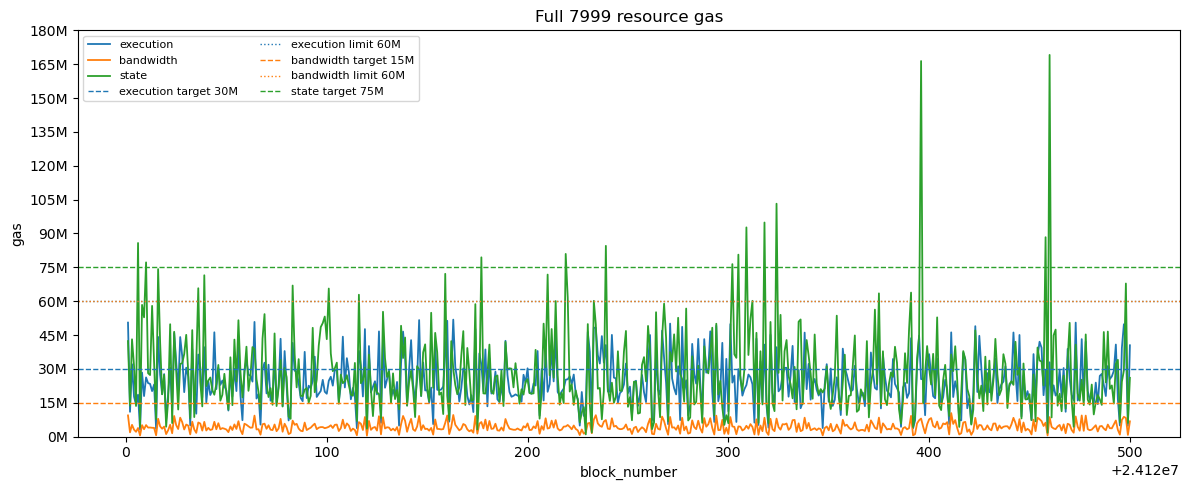

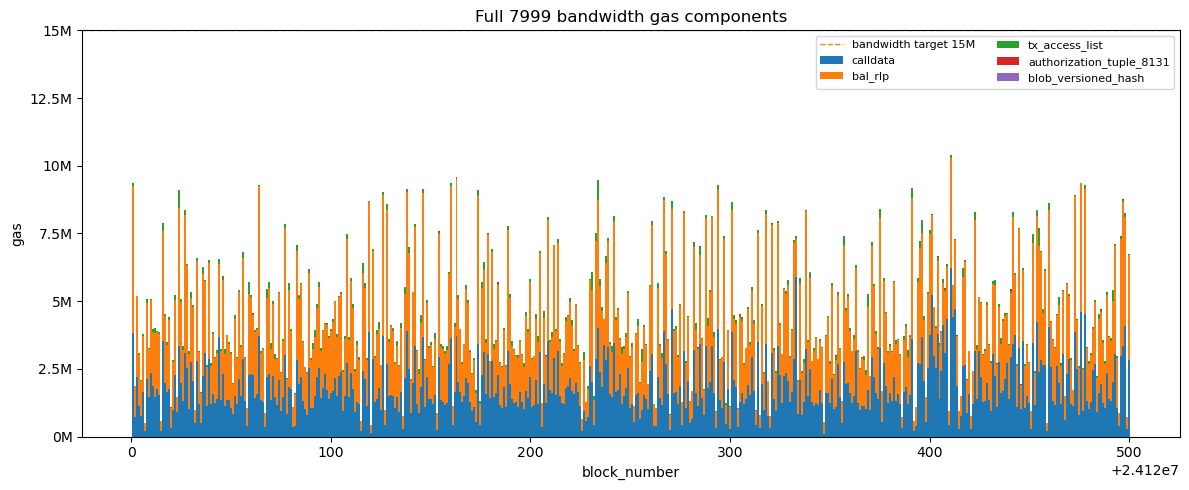

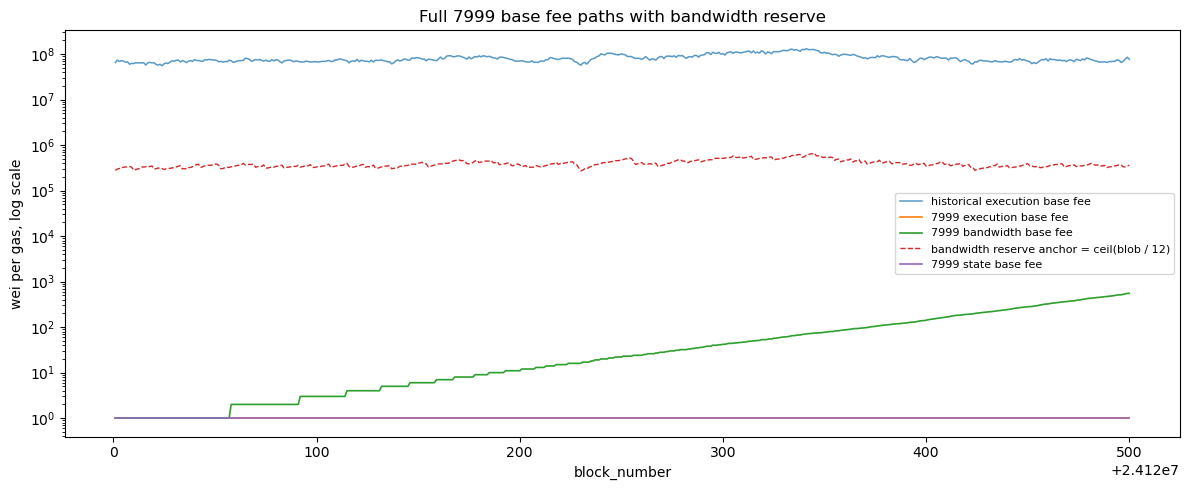

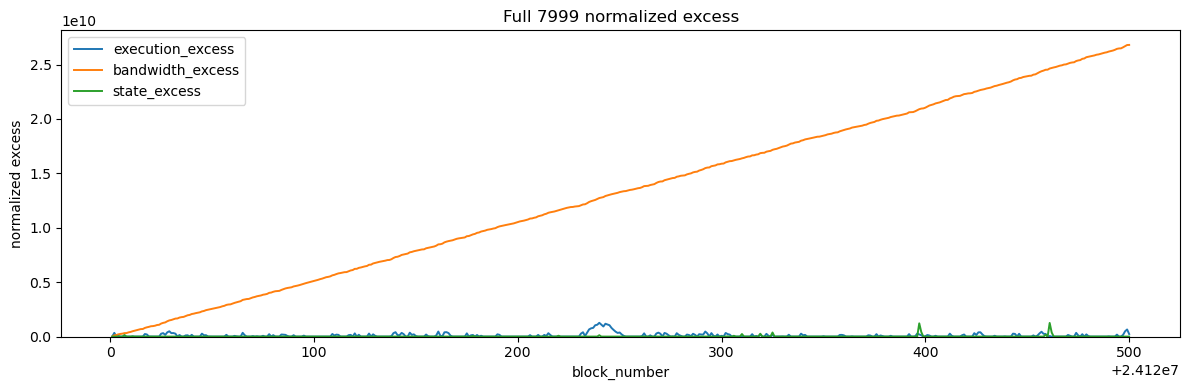

(PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/full_7999_resource_gas_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/full_7999_bandwidth_components_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/full_7999_base_fees_24120001_24120500.png'),
 PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/full_7999_excess_24120001_24120500.png'))

In [7]:
def set_million_axis(ax, series_names, reference_values=(), step=15_000_000):
    ymax = max([replay[name].max() for name in series_names] + list(reference_values))
    upper = int(((ymax + step - 1) // step) * step)
    ticks = list(range(0, upper + 1, step))
    ax.set_ylim(bottom=0, top=upper)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{tick // 1_000_000}M" for tick in ticks])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(replay["block_number"], replay["execution_gas_used"], label="execution", linewidth=1.3)
ax.plot(replay["block_number"], replay["bandwidth_gas_used"], label="bandwidth", linewidth=1.3)
ax.plot(replay["block_number"], replay["state_gas_used"], label="state", linewidth=1.3)
ax.axhline(EXECUTION_GAS_TARGET, color="tab:blue", linestyle="--", linewidth=1, label="execution target 30M")
ax.axhline(EXECUTION_GAS_LIMIT, color="tab:blue", linestyle=":", linewidth=1, label="execution limit 60M")
ax.axhline(BANDWIDTH_GAS_TARGET, color="tab:orange", linestyle="--", linewidth=1, label="bandwidth target 15M")
ax.axhline(BANDWIDTH_GAS_LIMIT, color="tab:orange", linestyle=":", linewidth=1, label="bandwidth limit 60M")
ax.axhline(STATE_GAS_TARGET, color="tab:green", linestyle="--", linewidth=1, label="state target 75M")
set_million_axis(
    ax,
    ["execution_gas_used", "bandwidth_gas_used", "state_gas_used"],
    [EXECUTION_GAS_LIMIT, BANDWIDTH_GAS_LIMIT, STATE_GAS_TARGET],
)
ax.set_title("Full 7999 resource gas")
ax.set_xlabel("block_number")
ax.set_ylabel("gas")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_RESOURCE_GAS_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
bar_bottom = pd.Series(0, index=replay.index, dtype="float64")
for component, _bytes_col, gas_col in component_specs:
    ax.bar(
        replay["block_number"],
        replay[gas_col],
        bottom=bar_bottom,
        label=component,
        width=1.0,
        linewidth=0,
    )
    bar_bottom = bar_bottom + replay[gas_col].astype("float64")
ax.axhline(BANDWIDTH_GAS_TARGET, color="tab:orange", linestyle="--", linewidth=1, label="bandwidth target 15M")
ax.set_ylim(bottom=0, top=15_000_000)
ax.set_yticks([0, 2_500_000, 5_000_000, 7_500_000, 10_000_000, 12_500_000, 15_000_000])
ax.set_yticklabels(["0M", "2.5M", "5M", "7.5M", "10M", "12.5M", "15M"])
ax.set_title("Full 7999 bandwidth gas components")
ax.set_xlabel("block_number")
ax.set_ylabel("gas")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_BANDWIDTH_COMPONENTS_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(replay["block_number"], replay["original_base_fee"], label="historical execution base fee", linewidth=1.1, alpha=0.75)
ax.plot(replay["block_number"], replay["execution_base_fee"], label="7999 execution base fee", linewidth=1.2)
ax.plot(replay["block_number"], replay["bandwidth_base_fee"], label="7999 bandwidth base fee", linewidth=1.2)
ax.plot(replay["block_number"], replay["bandwidth_reserve_anchor_base_fee"], label="bandwidth reserve anchor = ceil(blob / 12)", linewidth=1.0, linestyle="--")
ax.plot(replay["block_number"], replay["state_base_fee"], label="7999 state base fee", linewidth=1.2)
ax.set_title("Full 7999 base fee paths with bandwidth reserve")
ax.set_xlabel("block_number")
ax.set_ylabel("wei per gas, log scale")
ax.set_yscale("log")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_BASE_FEE_PLOT, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(replay["block_number"], replay["execution_excess"], label="execution_excess", linewidth=1.4)
ax.plot(replay["block_number"], replay["bandwidth_excess"], label="bandwidth_excess", linewidth=1.4)
ax.plot(replay["block_number"], replay["state_excess"], label="state_excess", linewidth=1.4)
ax.set_title("Full 7999 normalized excess")
ax.set_xlabel("block_number")
ax.set_ylabel("normalized excess")
ax.set_ylim(bottom=0)
ax.legend()
fig.tight_layout()
fig.savefig(OUT_EXCESS_PLOT, dpi=180)
plt.show()

OUT_RESOURCE_GAS_PLOT, OUT_BANDWIDTH_COMPONENTS_PLOT, OUT_BASE_FEE_PLOT, OUT_EXCESS_PLOT

## Interpretation

State is valid even when it spikes above `75M`, because full EIP-7999 treats state as a long-run target-controlled resource rather than a hard per-block cap. Execution and bandwidth still have hard limits.

Bandwidth/data uses the EIP-7999 reserve anchor against the historical blob base fee. The diagnostic anchor threshold is `ceil(blob_base_fee_per_gas / 12)`, but the base fee is not hard-clamped to that value. The reserve affects the excess-gas update path, so the bandwidth base fee climbs gradually when the reserve condition is active.

Execution and state integer base-fee columns are seeded at the minimum fee of `1`, so they can stay flat over a short replay even while normalized excess moves. Bandwidth also remains pure `fake_exponential(excess)`; the blob reserve anchor changes excess growth rather than applying an instant floor.

This notebook is passive replay only. It does not model demand response, transaction packing, or replacement of historical transactions that would have been priced differently.